# 132543 — sparse-grid point generation to GENE parameters files

**What this does.** Seed 132543 profiles + EQDSK → sparse-grid sampler proposes
points in three scaling axes → each point is reconstructed through CHEASE-BS into
its *own* EQDSK (filename carries the transform) and its *own* iterdb → each pair
is written into its *own* GENE parameters file under a temp directory.

**What this does not do.** Nothing is submitted. No GENE runs. No growth rates.
`_default_submitter` and `_job_finished` stay unexercised — the only never-run
campaign function this touches is `_write_parameters`.

**Read this before running.** With no GENE runs there is no QoI, and the grid
will not produce a second batch until the first is told. To get more than the
single seed point out of the sampler, this notebook tells it **fabricated**
values (`dummy_qoi`). The `session.json` it leaves behind is meaningless as a
scan and must never be resumed by a real campaign. Set `STEPS = 1` if you want
only the one honest point.

Run on NERSC — CHEASE-BS needs the compiled binary via
`TPED/config/user_config.yaml`.

## 1. Inputs you have to provide

These are NERSC-side files. Fill in every one that is `None`, then run the check
cell below and do not continue until it prints `all inputs present`.

In [1]:
# ---------------------------------------------------------------- REQUIRED

# Baseline GENE parameters file this scan perturbs. Neither this repo nor TPED
# has one for 132543 — high_triangularity/132543 holds only analysis notebooks.
# The 129015 one is the shape assumed here (magn_geometry='tracer_efit', EQDSK
# geomfile, profiles via iterdb_file, x0 set to the analysis radius):
#   TPED/data/discharges/NSTX129015/r_0.85_NE/scanfiles0000/parameters
BASE_PARAMETERS = "/global/homes/j/joeschm/simulators/GENE3/NSTX_132543_omne0.8_omt0.8_KBM_r0.7/parameters"
43
# The seed discharge. Two ways in — pick ONE and leave the other None.
#
#   SEED_DIRPATH  : directory holding 132543's EQDSK + pfile (or GENE profiles).
#                   Auto-discovered, same as the CHEASE-BS canary. PREFERRED:
#                   a pfile carries both rho_tor and rho_pol.
#   SEED_ITERDB   : a 132543 iterdb, converted to GENE profiles files on the way
#                   in. Needs SEED_GFILE alongside it, since CHEASE-BS
#                   reconstructs *from* a source equilibrium and an iterdb has
#                   no geometry. Caveat: an iterdb has rho_tor only, so the
#                   rho_pol column of the converted profiles is filled with
#                   rho_tor.
SEED_DIRPATH = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543"
SEED_ITERDB  = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/NSTX132543.iterdb"
SEED_GFILE   = "/global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/g132543.00700"            # required only when using SEED_ITERDB

# ---------------------------------------------------------------- OPTIONAL

# Where the generated equilibria and parameters files land. Gitignored.
OUTROOT = "tmp_runs"

# Single k_y for the inner scanlist. The QoI reduction names the same value,
# though nothing is harvested here.
KY = 0.05

# Refinement steps to walk. Batch 0 is ONE point, so 3 steps is roughly 5-10
# equilibria, not 3.
STEPS = 3

# Hard stop on reconstructions. Every one of these is a CHEASE-BS run.
MAX_POINTS = 12

# Prefix for the retagged per-point EQDSKs: g132543_Te1.100-ne0.900-wTe1.200
EQDSK_PREFIX = "g132543"

# Where reconstruction artifacts go: the cheaseBS acceptance record, run config,
# convergence summary, baseline gfile copy and profiles files. Kept out of the
# per-point run directories so <workdir>/bXXXXpXXXX holds a GENE run and nothing
# else -- parameters, its EQDSK, its iterdb -- and can be submitted, tarred or
# handed over exactly as a hand-built run would be. None puts them in
# <workdir>/_reconstruction; point it at scratch if they need not travel with
# the runs.
RECON_DIR = None

# cheaseBS iteration limit. NOT a cost knob to trim -- the solver under-relaxes
# its bootstrap and current updates (bootstrap_mix 0.1, istar_mix 0.05), so one
# iteration applies about a twentieth of the current update and returns an
# equilibrium still carrying the BASELINE current profile no matter how far the
# input profiles were moved. The template shipped max_iter=1 until 2026-08-18,
# justified by a canary that only ever ran identity reconstructions -- where the
# loop starts at its own fixed point and has nothing to converge, so iteration
# count could not matter. Roughly 1/istar_mix = 20 iterations are needed to
# apply one full current update, more to converge it.
CHEASEBS_OVERRIDES = {
    "max_iter": 25,

    # Write iteration_errors.png into each point's reconstruction directory and
    # refresh it every iteration: bootstrap change, q change, amplitude change
    # and Ip error, log scale, each with its tolerance drawn, the saturation
    # iteration marked, and the implied residual annotated.
    "plot_errors": True,

    # --- convergence tolerances -------------------------------------------
    #
    # THE KEY FACT: cheaseBS under-relaxes. x_new = (1-mix)*x_old +
    # mix*x_computed, so the change logged each iteration IS mix times the
    # residual. The tolerances therefore flatter the result by 1/mix:
    #
    #     tol_bs 0.01 at bootstrap_mix 0.1  ->  accepts a 10% residual
    #     tol_q  0.01 at istar_mix     0.05 ->  accepts a 20% residual
    #
    # They read as 1% and behave like 10-20%. That is why "everything else was
    # met" at iteration 1 while Ip was still drifting monotonically at iteration
    # 13 of the 25-iteration run: a loop whose change is flat rather than
    # decaying has not converged, it is creeping. The tolerances were too LOOSE,
    # not too tight.
    #
    # REVISED AGAIN once perturbed points were compared. The change metrics are
    # small for a reason that is not under-relaxation: the perturbation enters
    # at iteration 0. Thermal pressure and the kinetic profiles are direct
    # inputs, so CHEASE sees the new pedestal on the first solve, and only the
    # bootstrap feedback is iterative. bs_change from iteration 1 onward is
    # therefore a second-order correction on top of an already-applied change --
    # which is why iteration 0 logs bs_change=n/a, and why a 30% pedestal rise
    # still shows ~1e-4. The geometry does respond: Ip error moves 1.62% ->
    # 0.76% across the ne_ped_scale points.
    #
    # 1e-4 (residual ~1e-3 in bootstrap current) still demands at least one real
    # feedback step. Going to 1e-5 forced all 25 iterations chasing a refinement
    # around 1e-4, which cannot move a growth rate.
    #
    # To measure rather than argue: set tol_bs/tol_q to 1e-12 for ONE point so
    # nothing converges, let it run the full 25, and read the saturation marker
    # off iteration_errors.png. That is the evidence these numbers should come
    # from.
    "tol_bs": 1e-4,
    "tol_q": 1e-4,

    # Ip is an OUTPUT here, not a target: with qspec=on CHEASE imposes the q
    # profile, which fixes the current, and amplitude_next stayed pinned at
    # 1.000 for all 25 iterations. 0.02 clears the structural ~1.6% offset so
    # this stops vetoing `converged`; the acceptance gate still rejects Ip drift
    # independently at max_ip_error_rel = 0.03.
    "tol_ip_rel": 0.02,

    # Passed so the error plot can convert change into residual. Same values as
    # the template -- restated so the conversion stays correct if it changes.
    "bootstrap_mix": 0.1,
    "istar_mix": 0.05,
}

In [2]:
import os, sys, json
from datetime import datetime

sys.path.insert(0, os.path.abspath("."))
import pilot_helpers as ph

required = {"BASE_PARAMETERS": BASE_PARAMETERS}
if SEED_ITERDB:
    required.update({"SEED_ITERDB": SEED_ITERDB, "SEED_GFILE": SEED_GFILE})
else:
    required.update({"SEED_DIRPATH": SEED_DIRPATH})

print("inputs:")
missing = ph.check_inputs(required)
print()
print("imported TPED:")
tped_missing = ph.check_tped()

if BASE_PARAMETERS and os.path.exists(BASE_PARAMETERS):
    notes = ph.check_template(BASE_PARAMETERS)
    print("\ntemplate check:")
    for n in notes:
        print(f"  ! {n}")
    if not notes:
        print("  nothing to flag")

inputs:
  BASE_PARAMETERS  ok         file: /global/homes/j/joeschm/simulators/GENE3/NSTX_132543_omne0.8_omt0.8_KBM_r0.7/parameters
  SEED_ITERDB      ok         file: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/NSTX132543.iterdb
  SEED_GFILE       ok         file: /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/g132543.00700

all inputs present

imported TPED:
scan_campaign      /global/homes/j/joeschm/tools/TPED/projects/GENE_pipelines/src/scan_campaign.py
point_reconstruction /global/homes/j/joeschm/tools/TPED/projects/GENE_pipelines/src/point_reconstruction.py

  [ok] kymin seeded before add_scan (a9d09ea)
  [ok] namelists passed explicitly (b2e5190)
  [ok] no hand-added quotes on paths (b2e5190)
  [ok] parameters file read back after write (b2e5190)
  [ok] per-point iterdb (8cfdf49)
  [ok] scan axes kept out of the namelist (8cfdf49)
  [ok] pilot axes registered

imported TPED has every fix this notebook depends on

template check:
  ! templat

## 2. Workdir and the dummy-session warning

Everything this notebook writes goes under one timestamped directory, including
the poisoned `session.json`.

In [3]:
WORKDIR = os.path.abspath(os.path.join(OUTROOT, datetime.now().strftime("%Y%m%d_%H-%M-%S")))
os.makedirs(WORKDIR, exist_ok=True)

with open(os.path.join(WORKDIR, "WARNING-DUMMY-SESSION.txt"), "w") as f:
    f.write("session.json here was advanced with fabricated QoI values by the\n"
            "132543 parameter-generation notebook. The sampler state is\n"
            "meaningless. Do not resume a real campaign from this directory.\n")

print(WORKDIR)

/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21


## 3. Load the seed discharge

In [4]:
if SEED_ITERDB:
    print("seed: iterdb + gfile")
    discharge = ph.seed_from_iterdb(SEED_ITERDB, SEED_GFILE, WORKDIR)
else:
    print("seed: directory auto-discovery")
    discharge = ph.seed_from_dirpath(SEED_DIRPATH)

print("  gfile   ", discharge.gfile_filepath)
print("  pfile   ", discharge.pfile_filepath)
print("  profiles", discharge.profiles_filepaths)

seed: iterdb + gfile


number of points: 4000
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/seed_profiles/profiles_e  (4000 points, Te in eV, ne in m^-3)
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/seed_profiles/profiles_i  (4000 points, Ti in eV, ni in m^-3)
  [seed] wrote /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/seed_profiles/profiles_z  (4000 points, Tz in eV, nz in m^-3)
  gfile    /global/homes/j/joeschm/data/ST_research/NSTXU_discharges/132543/g132543.00700
  pfile    None
  profiles ['/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/seed_profiles/profiles_e', '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/seed_profiles/profiles_i', '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/s

## 4. Sanity-check the nominal mtanh fit

The scan axes are **scale factors on this fit**, so a bad fit does not produce a
bad point — it silently redefines what every axis value means. Check
`rms_relative` and look at the pedestal parameters before spending CHEASE-BS
runs.

In [5]:
from TPED.projects.discharge_tools.src.discharge_physics import DischargePhysics
from TPED.projects.discharge_tools.src.transforms.mtanh_transforms import fit_mtanh
from TPED.projects.GENE_pipelines.src.point_reconstruction import (
    PILOT_BOUNDS_132543, MTANH_AXES, MTANH_FIT_KWARGS, nominal_fits,
    is_equilibrium_axis)

phys0 = DischargePhysics(discharge)

for var in sorted({v for v, _ in MTANH_AXES.values()}):
    profile, record = fit_mtanh(phys0.ds, var, **MTANH_FIT_KWARGS)
    print(f"{var}:  rms_relative = {record['rms_relative']:.4f}")
    # fit_params is MtanhProfile.as_dict() -- a dict, not a sequence. Zipping a
    # key list against it iterates the dict's KEYS, so v came back a string.
    for k, v in record["fit_params"].items():
        print(f"    {k:<10} {v: .6g}")

print("\naxes and bounds (scale factors on the fit above):")
for name, (lo, hi) in PILOT_BOUNDS_132543.items():
    var, kwarg = MTANH_AXES[name]
    print(f"  {name:<16} {var:<3} {kwarg:<13} [{lo}, {hi}]")

Te:  rms_relative = 0.0052
    y_sep       47.9481
    a_y0        146.976
    delta_ped   0.135972
    psi_mid     0.903616
    a_y1        649.609
    psi_ped     0.8
    alpha_1     3.16861
    alpha_2     2.68958
ne:  rms_relative = 0.0029
    y_sep       2.77284e+19
    a_y0        1.83493e+19
    delta_ped   0.102495
    psi_mid     0.947545
    a_y1        4.44314e+19
    psi_ped     0.98
    alpha_1     1.36564
    alpha_2     3.31341

axes and bounds (scale factors on the fit above):
  Te_ped_scale     Te  scale_height  [0.7, 1.3]
  ne_ped_scale     ne  scale_height  [0.7, 1.3]
  Te_width_scale   Te  scale_width   [0.6, 1.4]


Plot the seed pedestal against the fit, and against the corners of the box —
this is the cheapest way to see whether ±30% produces profiles you would
actually want CHEASE-BS to try.

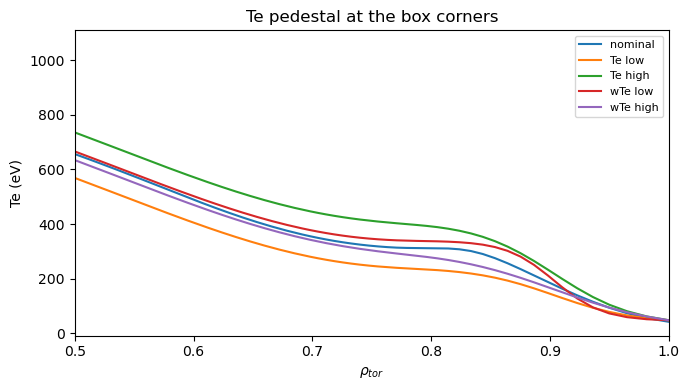

In [6]:
import matplotlib.pyplot as plt

fits = nominal_fits(phys0, set(PILOT_BOUNDS_132543))
corners = [
    ("nominal",  {}),
    ("Te low",   {"Te_ped_scale": PILOT_BOUNDS_132543["Te_ped_scale"][0]}),
    ("Te high",  {"Te_ped_scale": PILOT_BOUNDS_132543["Te_ped_scale"][1]}),
    ("wTe low",  {"Te_width_scale": PILOT_BOUNDS_132543["Te_width_scale"][0]}),
    ("wTe high", {"Te_width_scale": PILOT_BOUNDS_132543["Te_width_scale"][1]}),
]

fig, ax = plt.subplots(figsize=(7, 4))
for label, point in corners:
    from TPED.projects.GENE_pipelines.src.point_reconstruction import _apply_axes
    p = _apply_axes(phys0, point, fits=fits) if point else phys0
    ax.plot(p.rhot, p.Te, label=label, lw=1.5)
ax.set_xlim(0.5, 1.0); ax.set_xlabel(r"$\rho_{tor}$"); ax.set_ylabel("Te (eV)")
ax.legend(fontsize=8); ax.set_title("Te pedestal at the box corners")
plt.tight_layout(); plt.show()

## 5. Build the sampler and the campaign

The submitter is replaced with one that writes the parameters file and stops.
Everything before that — the sampler, `reconstruct_point`, the acceptance gate,
the ledger, `_write_parameters` — is the production path.

In [7]:
from TPED.projects.discharge_tools.src.cheasebs_runner import CheasebsAcceptance
from TPED.projects.GENE_pipelines.src.sparse_scan_driver import SparseScanSession
from TPED.projects.GENE_pipelines.src.scan_campaign import (
    GeneScanCampaign, QoISpec, HARVESTED, PENDING, REJECTED)

# The radii the existing 132543 linear scans sit at: r_0.736 (q=4), r_0.825
# (q=5). The gate checks q here, so a point whose q has moved where the physics
# is read gets rejected rather than silently scanned.
GENE_RADII = (0.736, 0.825)

AXIS_SHORT = {"Te_ped_scale": "Te", "ne_ped_scale": "ne", "Te_width_scale": "wTe"}

sampler = SparseScanSession(PILOT_BOUNDS_132543,
                            state_path=os.path.join(WORKDIR, "session.json"))
print(PILOT_BOUNDS_132543)

campaign = GeneScanCampaign(
    sampler=sampler,
    base_discharge=discharge,
    qoi=QoISpec(quantity="gamma", reduction="at_ky", ky=KY),
    workdir=WORKDIR,
    base_parameters=os.path.abspath(BASE_PARAMETERS),
    acceptance=CheasebsAcceptance.production(analysis_radii=GENE_RADII),
    ky_scanlist=[KY],
    recon_dir=RECON_DIR,
    cheasebs_overrides=CHEASEBS_OVERRIDES,
)
campaign.submitter = ph.write_parameters_only(campaign)
print("campaign ready")

{'Te_ped_scale': (0.7, 1.3), 'ne_ped_scale': (0.7, 1.3), 'Te_width_scale': (0.6, 1.4)}
campaign ready


## 6. Generate

Per step: propose points → reconstruct + gate each through CHEASE-BS → rename
each accepted EQDSK to carry its transform → write its parameters file → tell
the sampler fabricated values so the next step produces new points.

This is the slow cell. Each point is a CHEASE-BS run.

[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000/cheasebs_run_config.json
Starting iterative CHEASE workflow (coordinate=rhop, replay=istar, qspec=on)
Output directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000
Baseline directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000/cheasebs_baseline
Run targets: Ip=947061.789 A (source 947061.789 A), Bt=-0.439262 T (source -0.439262 T)
Rebuilding baseline decomposition from reference profiles
Preparing baseline inputs from g132543.00700
Baseline radial mapping complete
Baseline Step 1 complete: thermal/fast pressure split and Zeff
Baseline Step 2 complete: bootstrap/driven current decomposition
Baseline outputs written
Baseline rebuild complete: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000/cheasebs_baseline
Starting iterative replay with target Ip=947061.78

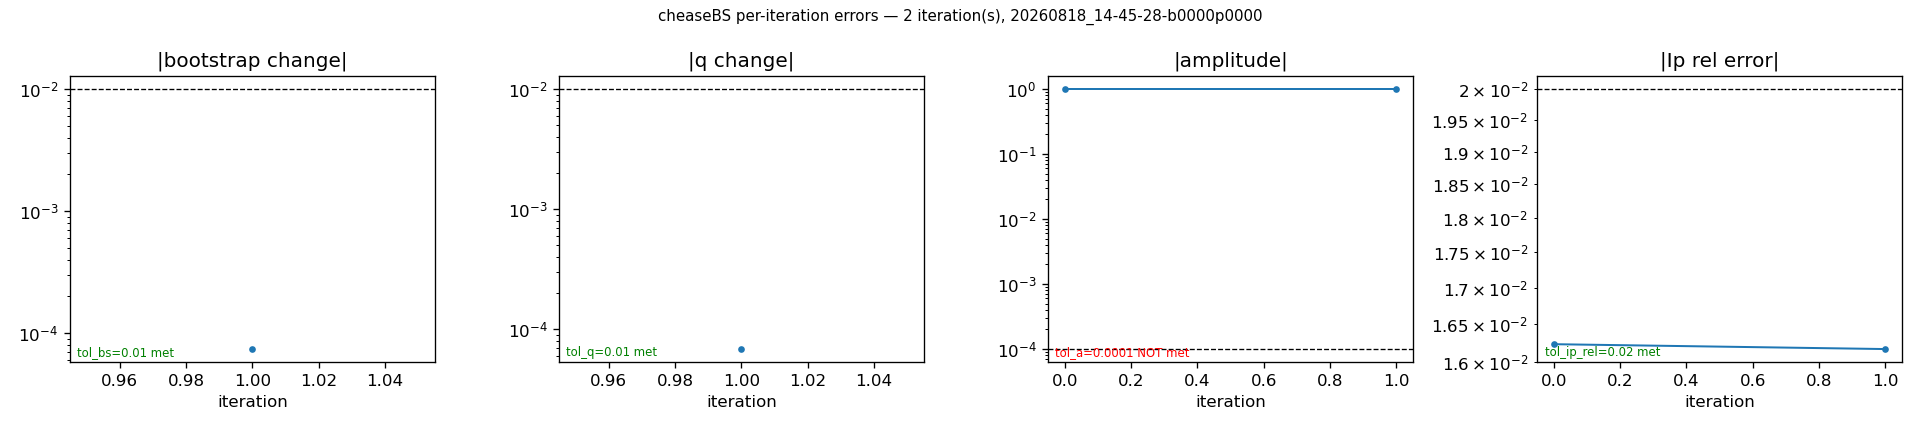

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.617%  (final 931749.1 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.613%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.514%   (deviation from source)
[cheaseBS]   q95 error        0.836%
[cheaseBS]   q edge error    16.921%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
step 0: 1 point(s), 1 accepted, 0 rejected
    b0000p0000 eqdsk -> g132543_Te1.000-wTe1.000-ne1.000
    advanced the grid on 1 fabrica

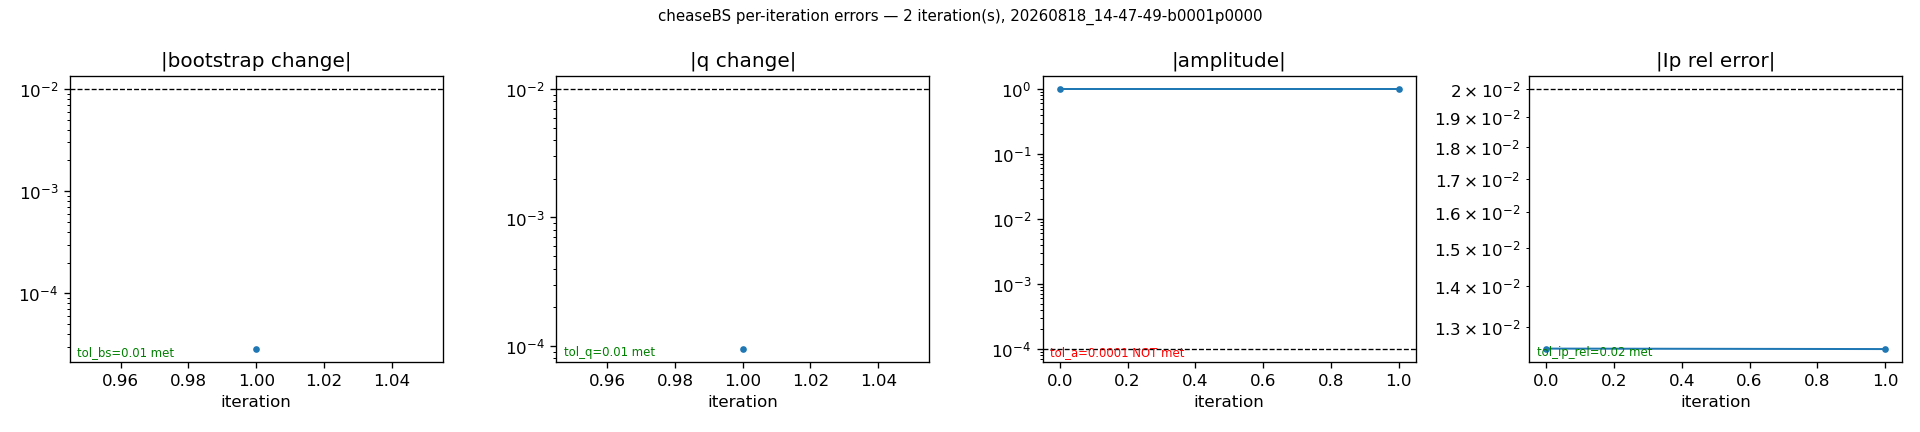

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-47-49-b0001p0000/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.249%  (final 935228.7 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.648%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.379%   (deviation from source)
[cheaseBS]   q95 error        0.931%
[cheaseBS]   q edge error    17.024%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-47-49-b0001p0000
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0001p0000/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheas

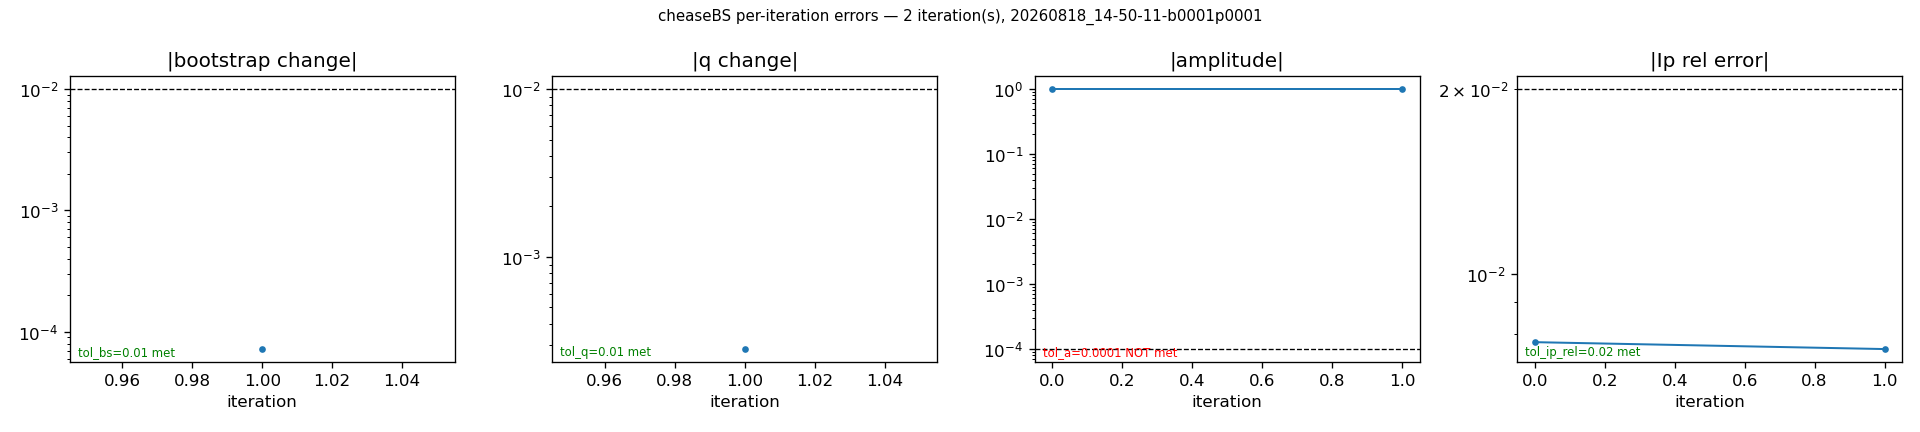

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-50-11-b0001p0001/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         0.755%  (final 939908.5 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.892%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.444%   (deviation from source)
[cheaseBS]   q95 error        0.836%
[cheaseBS]   q edge error    17.174%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-50-11-b0001p0001
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0001p0001/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
[cheaseBS] running: /global/homes/j/joeschm/simulators/cheaseBS/run_chease_iterative_profiles.py --config /pscratch/sd/j/joeschm/cheas

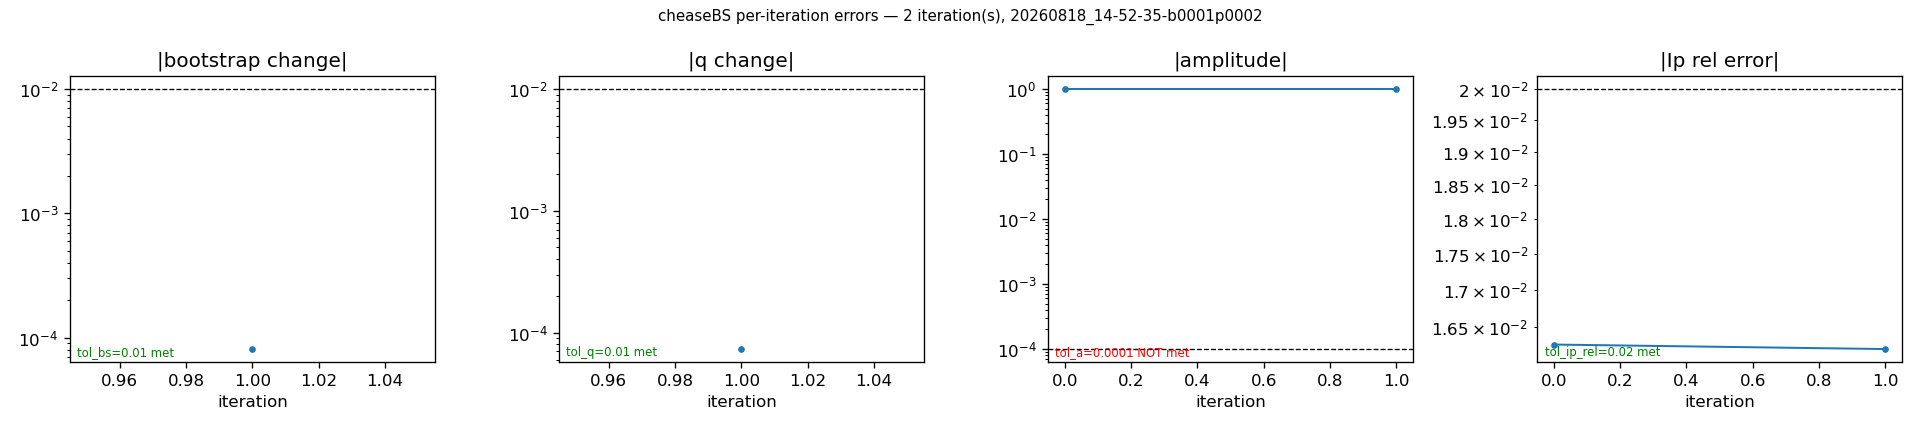

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-52-35-b0001p0002/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.621%  (final 931712.5 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.643%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.515%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.920%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-52-35-b0001p0002
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0001p0002/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
step 1: 3 point(s), 3 accepted, 0 rejected
    b0001p0000 eqdsk -> g132543_Te1.300-wTe1.000-ne1.000
    b0001p0001 eqdsk -> g132543_Te

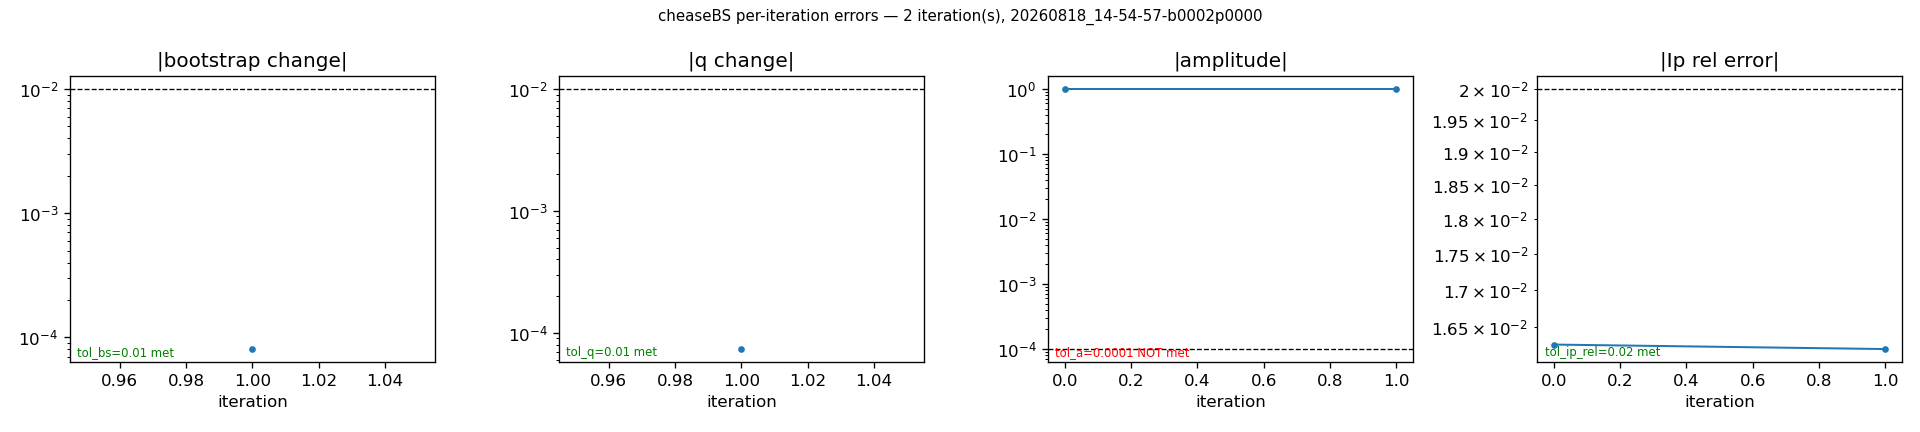

[cheaseBS] error plot: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-54-57-b0002p0000/iteration_errors.png
[cheaseBS] acceptance: ACCEPTED
[cheaseBS]   Ip error         1.621%  (final 931712.3 A vs reference 947061.8 A)
[cheaseBS]   q @ rho_tor 0.736   0.643%   (deviation from source)
[cheaseBS]   q @ rho_tor 0.825   0.515%   (deviation from source)
[cheaseBS]   q95 error        0.834%
[cheaseBS]   q edge error    16.920%   <- separatrix-adjacent, see module docstring
[cheaseBS]   solver flag    converged=True (2 iteration(s)) — recorded, not gated by default
[cheaseBS] scratch run directory: /pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-54-57-b0002p0000
[cheaseBS] new equilibrium written to: /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0002p0000/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT
step 2: 1 point(s), 1 accepted, 0 rejected
    b0002p0000 eqdsk -> g132543_Te1.000-wTe1.000-ne0.700
    advanced the grid on 1 fabrica

In [8]:
proposed = 0
for step in range(STEPS):
    accepted = campaign.propose()
    batch = campaign.ledger.batch(step)
    proposed += len(batch)
    print(f"step {step}: {len(batch)} point(s), {len(accepted)} accepted, "
          f"{len(batch) - len(accepted)} rejected")
    for e in batch:
        if e.status == REJECTED:
            print(f"    {e.point_id} REJECTED — {e.note}")

    renamed = ph.retag_eqdsks(campaign, step, EQDSK_PREFIX, AXIS_SHORT)
    for pid, path in renamed.items():
        print(f"    {pid} eqdsk -> {os.path.basename(path)}")

    submitted = campaign.submit_pending()
    stuck = [e for e in campaign.ledger.batch(step) if not e.rundir and e.eqdsk]
    for e in stuck:
        print(f"    {e.point_id} PARAMETERS FAILED — {e.note}")

    # Stop here rather than advancing. submit_pending() records the failure
    # reason in the ledger note, and the DUMMY_QOI update below overwrites that
    # note -- so advancing past a failed write destroys the only diagnostic
    # there is, which is exactly what happened on the 22-27-39 run.
    if stuck:
        print(f"\n{len(stuck)} point(s) reconstructed but produced no parameters "
              f"file. Stopping so the ledger keeps the reason.")
        break

    if proposed >= MAX_POINTS:
        print(f"point cap {MAX_POINTS} reached, stopping"); break
    if not accepted:
        print("nothing accepted this step — stopping rather than spending "
              "CHEASE-BS runs on a box the gate rejects"); break
    if len(accepted) != len(batch):
        print("batch incomplete, so the grid cannot advance; stopping"); break

    for e in campaign.ledger.batch(step):
        campaign.ledger.update(e.point_id, status=HARVESTED,
                               qoi=ph.dummy_qoi(e.point), note="DUMMY_QOI")
    campaign.tell_batch(step)
    print(f"    advanced the grid on {len(submitted)} fabricated value(s)")

## 7. Did it work?

Reads every written parameters file back. The three silent failure modes: a scan
axis written into the namelist as a GENE key, an `iterdb_file` still pointing at
the seed, and a `geomfile` that is not this point's EQDSK.

In [9]:
problems = ph.verify_parameters(campaign, is_equilibrium_axis)

for e in campaign.ledger.entries.values():
    if not e.rundir:
        continue
    print(f"{e.point_id}  {json.dumps(e.point, sort_keys=True)}")
    print(f"    eqdsk   {e.eqdsk}")
    print(f"    iterdb  {e.iterdb}")
    print(f"    params  {os.path.join(e.rundir, 'parameters')}")

if problems:
    print(f"\n{len(problems)} PROBLEM(S):")
    for pid, msg in problems:
        print(f"  {pid}: {msg}")
else:
    print("\nno problems found in the written parameters files")

b0000p0000  {"Te_ped_scale": 1.0, "Te_width_scale": 1.0, "ne_ped_scale": 1.0}
    eqdsk   /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000/g132543_Te1.000-wTe1.000-ne1.000
    iterdb  /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000/profiles.iterdb
    params  /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/b0000p0000/parameters
b0001p0000  {"Te_ped_scale": 1.3, "Te_width_scale": 1.0, "ne_ped_scale": 1.0}
    eqdsk   /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0001p0000/g132543_Te1.300-wTe1.000-ne1.000
    iterdb  /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0001p0000/profiles.iterdb
    params  /global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/t

Print one parameters file in full — the automated checks only catch what they
were told to look for.

In [10]:
written = [e for e in campaign.ledger.entries.values() if e.rundir]
if written:
    print(open(os.path.join(written[0].rundir, "parameters")).read())
else:
    print("nothing was written")

&parallelization
n_procs_s = 1
n_procs_v = 1
n_procs_w = 4
n_procs_x = 1
n_procs_y = 1
n_procs_z = 1
n_procs_sim = 4
n_parallel_sims = 6
/

&box
n_spec = 3
nx0 = 3
nky0 = 1
nz0 = 64
nv0 = 36
nw0 = 32
n0_global = 1 !scanlist: 10, 20, 30, 50, 70, 100
lv = 3.0
lw = 9
lx = 129
adapt_lx = T
adapt_ly = T
x0 = 0.7
kymin = 0.05 !scanlist: 0.05
/

&in_out
diagdir = '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/b0000p0000'
read_checkpoint = F
write_checkpoint = T
istep_field = 100
istep_mom = 100
istep_nrg = 100
istep_vsp = 400
istep_schpt = 5000
iterdb_file = '/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/b0000p0000/profiles.iterdb'
/

&general
nblocks = 1
perf_vec = '1 1 1 1 1 1 1 1 2'
calc_dt = T
nonlinear = F
comp_type = 'IV'
arakawa_zv = F
timescheme = 'RK4'
timelim = 86000
ntimesteps = 750000
beta = -1
debye2 = -1
collision_op = 'landau'
coll = -1
coll_cons_model = 'xu_rosenbluth'
init_cond =

## 8. Every generated profile, side by side

Reads each point's `profiles_e` / `profiles_i` back off disk — what CHEASE-BS
was actually handed, not a recomputation of the transform. The check that
matters is the last one: if two points share a profile, the transform did not
take, and every CHEASE-BS run would still have succeeded while the axes scanned
nothing.

In [11]:
profile_rows = ph.summarize_profiles(campaign, AXIS_SHORT)

difference column is measured against b0000p0000 (Te1.000-wTe1.000-ne1.000)

point_id     tag                                   Te_ped    ne_ped  |gradTe|  dTe vs ref
-----------------------------------------------------------------------------------------
b0000p0000   Te1.000-wTe1.000-ne1.000              0.1644     5.332     2.119      0.0000
b0001p0000   Te1.300-wTe1.000-ne1.000              0.1994     5.332     2.755      0.0854
b0001p0001   Te1.000-wTe1.000-ne1.300              0.1644     6.099     2.119      0.0000
b0001p0002   Te1.000-wTe1.400-ne1.000              0.1505     5.332     1.528      0.0409
b0002p0000   Te1.000-wTe1.000-ne0.700              0.1644     4.565     2.119      0.0000

all 5 profiles differ from each other


In [12]:
ph.plot_profiles(profile_rows)

The same points through discharge_tools' own plotting, rebuilt from each
point's written profiles and its own reconstructed EQDSK. `full=True` swaps the
profiles-only view for the report layout, which adds the flux-surface geometry —
the only view here that shows whether the *equilibria* differ rather than just
the profiles that produced them.

### Did cheaseBS actually converge?

Read the iteration count before reading anything else on this page. An
equilibrium that stopped at iteration 1 is not converged — it is the baseline
current profile with different input profiles underneath, because the solver
under-relaxes and one iteration applies a fraction of the update. If every point
stops at exactly `CHEASEBS_OVERRIDES['max_iter']`, the tolerances were never met and the
error below is what the solver *achieved*, not what it promised.

In [13]:
conv_rows = ph.convergence_report(campaign)

point_id      iters  solver conv     Ip err     gate
----------------------------------------------------
b0000p0000        2         True     1.617%   accept
b0001p0000        2         True     1.249%   accept
b0001p0001        2         True     0.755%   accept
b0001p0002        2         True     1.621%   accept
b0002p0000        2         True     1.621%   accept

iterations: min 2, max 2


Per-iteration history, which is the evidence `max_iter` and the tolerances
should actually be set from. A curve that flattens well before the cap means the
cap can come down; one still descending at the cap means it must go up; one that
never moves means the loop is not responding at all. Dashed lines are the
tolerances the loop was judged against.

`iteration_log.csv` is written by cheaseBS into its scratch run directory and is
only copied back as of the 2026-08-18 change — runs older than that will report
it missing.

In [14]:
ph.plot_convergence(
    campaign,
    tolerances={"bootstrap change": 0.01,   # tol_bs
                "q change": 0.01,           # tol_q
                "amplitude": 1e-4,          # tol_a
                "Ip error": 0.002},         # tol_ip_rel -- the unreachable one
)

point_id      iters   bootstrap change           q change          amplitude           Ip error
b0000p0000        2          7.377e-05          6.867e-05          1.000e+00          1.617e-02
b0001p0000        2          2.853e-05          9.451e-05          1.000e+00          1.249e-02
b0001p0001        2          7.204e-05          2.821e-04          1.000e+00          7.553e-03
b0001p0002        2          8.119e-05          7.329e-05          1.000e+00          1.621e-02
b0002p0000        2          8.051e-05          7.340e-05          1.000e+00          1.621e-02


[(LedgerEntry(point_id='b0000p0000', batch=0, point={'Te_ped_scale': 1.0, 'ne_ped_scale': 1.0, 'Te_width_scale': 1.0}, status='told', eqdsk='/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000/g132543_Te1.000-wTe1.000-ne1.000', iterdb='/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000/profiles.iterdb', savedir='/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/_reconstruction/b0000p0000', rundir='/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/b0000p0000', job_id='DRYRUN', qoi=0.8467200483592032, acceptance={'accepted': True, 'cheasebs_converged': True, 'cheasebs_iterations': 2, 'eqdsk': '/pscratch/sd/j/joeschm/cheaseBS_runs/20260818_14-45-28-b0000p0000/iteration_01/artifacts/EQDSK_COCOS_02_POS_SOURCE_SIGNS.OUT', 'final_ip_a': 931749.1321, 'ip_error_rel': 

## 9. Do the equilibria differ?

Flux-surface contours are the wrong instrument for this question and will
mislead. The reconstruction preserves the source EFIT boundary by design, and a
pedestal perturbation is a small fraction of stored energy — so the separatrix
*cannot* move, and interior surfaces shift by far less than a contour plot
resolves. Identical-looking flux surfaces are the expected result, not evidence
that nothing happened.

What must move is the flux functions. The table below gives the max relative
difference of F, p, p', FF', q and the 2-D psi map against the reference point,
and the normalized flux coordinate where that max sits — which is the part
overlapping curves cannot tell you. It also checks the boundary really did stay
fixed, since a boundary that moved would be a finding.

In [15]:
gfile_rows = ph.compare_gfiles(campaign, AXIS_SHORT)

reference: b0000p0000 (Te1.000-wTe1.000-ne1.000)
boundary points: 300, flux grid: 513

max relative difference vs reference
point_id     tag                                      F           p      pprime     ffprime           q      psi_RZ
-------------------------------------------------------------------------------------------------------------------
b0000p0000   Te1.000-wTe1.000-ne1.000         0.000e+00   0.000e+00   0.000e+00   0.000e+00   0.000e+00   0.000e+00
b0001p0000   Te1.300-wTe1.000-ne1.000         2.255e-03   2.129e-02   1.852e-01   4.039e-01   3.850e-03   1.051e-02
b0001p0001   Te1.000-wTe1.000-ne1.300         4.849e-03   3.856e-02   2.393e-01   1.299e+00   5.239e-03   2.505e-02
b0001p0002   Te1.000-wTe1.400-ne1.000         1.693e-04   1.329e-03   4.427e-02   1.113e-01   2.126e-04   1.039e-04
b0002p0000   Te1.000-wTe1.000-ne0.700         1.693e-04   1.329e-03   4.427e-02   1.113e-01   2.127e-04   1.041e-04

where the max occurs (rho_tor, 0=axis 1=edge)
point_id     tag 

Differences, not overlays — a sub-percent change between two curves drawn on
the same axes is one curve.

In [21]:
ph.plot_gfile_differences(gfile_rows)

In [22]:
fig = ph.plot_discharge_overlay(campaign, AXIS_SHORT, rhot=[0.85, 1.0])

overlaid 5 point(s)


In [23]:
# Slower: reads every point's EQDSK and draws its flux surfaces.
fig = ph.plot_discharge_overlay(campaign, AXIS_SHORT, full=True, rhot=[0.6, 1.0])

overlaid 5 point(s)


In [24]:
print(campaign.ledger)

## 10. Summary record

In [20]:
summary = os.path.join(WORKDIR, "pilot_summary.json")
with open(summary, "w") as f:
    json.dump({
        "workdir": WORKDIR,
        "base_parameters": os.path.abspath(BASE_PARAMETERS),
        "seed": {"dirpath": SEED_DIRPATH, "iterdb": SEED_ITERDB,
                 "gfile": SEED_GFILE},
        "axes": PILOT_BOUNDS_132543,
        "ky": KY,
        "analysis_radii": list(GENE_RADII),
        "qoi_values_are_fabricated": True,
        "profiles": [{k: v for k, v in r.items()
                      if k not in ("rhot", "Te", "ne", "Ti")}
                     for r in profile_rows],
        "problems": problems,
        "points": [{"point_id": e.point_id, "batch": e.batch, "point": e.point,
                    "status": e.status, "eqdsk": e.eqdsk, "iterdb": e.iterdb,
                    "rundir": e.rundir, "note": e.note}
                   for e in campaign.ledger.entries.values()],
    }, f, indent=1)
print(summary)

/global/u1/j/joeschm/projects/NSTXU_lithium_study/pilot_scan_132588/tmp_runs/20260818_14-45-21/pilot_summary.json
